# Kernels, filters and feature maps

**Learning objective:** Apply interpretable edge filters and observe how different kernels produce different spatial responses.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:15:33.105582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974933.120861    3787 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974933.125231    3787 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:15:34.830194: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


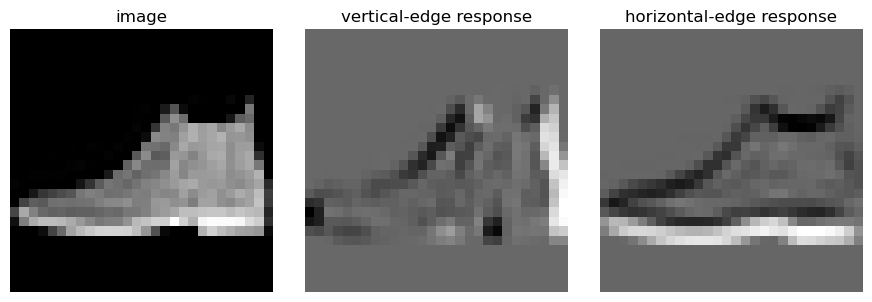

In [2]:
(_, _),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data(); img=x_test[0].astype("float32")/255
kx=np.array([[1,0,-1],[2,0,-2],[1,0,-1]],dtype="float32"); ky=kx.T
def apply(k): return tf.nn.conv2d(img[None,:,:,None],k[:,:,None,None],1,"SAME").numpy()[0,:,:,0]
fx,fy=apply(kx),apply(ky)
fig,axes=plt.subplots(1,3,figsize=(9,3));
for ax,a,t in zip(axes,[img,fx,fy],["image","vertical-edge response","horizontal-edge response"]): ax.imshow(a,cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()


A learned CNN begins with random filters and discovers useful patterns from the task loss. Every output channel is a separate learned feature map.


In [3]:
layer=tf.keras.layers.Conv2D(16,3,padding="same")
out=layer(tf.zeros((4,28,28,1)))
print("16 filters -> output shape:",out.shape,"kernel tensor:",layer.kernel.shape)


16 filters -> output shape: (4, 28, 28, 16) kernel tensor: (3, 3, 1, 16)
